# GRQ-PatchTST Training Notebook

Runs GRQ-PatchTST only. Loads existing LSTM/PatchTST/Persistence results from Drive for comparison.
Do NOT retrain baselines — they are already saved.

In [2]:
# ── Cell 1: Setup ─────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/drive/MyDrive/dl-energy-forecasting')

import torch, yaml, pickle, json, numpy as np
from torch.utils.data import DataLoader, TensorDataset
from utils.seed import set_seed
from utils.metrics import compute_all_metrics

BASE   = '/content/drive/MyDrive/dl-energy-forecasting'
device = torch.device('cuda')
print('GPU:', torch.cuda.get_device_name(0))

with open(f'{BASE}/config.yaml') as f:
    config = yaml.safe_load(f)

with open(f'{BASE}/data/processed.pkl', 'rb') as f:
    data = pickle.load(f)

train_df    = data['train']
val_df      = data['val']
test_df     = data['test']
feat_cols   = data['feature_cols']
target_cols = data['target_cols']
scaler      = data['scaler']

print('Target cols:', target_cols)
print('Feat cols (with indices):')
for i, c in enumerate(feat_cols):
    print(f'  [{i}] {c}')

# ── build windows ─────────────────────────────────────────────────────────
def make_windows(df, feature_cols, target_cols, lookback=168, horizon=24):
    d = df[feature_cols].values
    t = df[target_cols].values
    X, Y = [], []
    for i in range(len(d) - lookback - horizon + 1):
        X.append(d[i:i+lookback])
        Y.append(t[i+lookback:i+lookback+horizon].T)
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

L, H = config['lookback'], config['horizon']
X_train, Y_train = make_windows(train_df, feat_cols, target_cols, L, H)
X_val,   Y_val   = make_windows(val_df,   feat_cols, target_cols, L, H)
X_test,  Y_test  = make_windows(test_df,  feat_cols, target_cols, L, H)

print(f'Windows — Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(Y_train)),
                          batch_size=config['batch_size'], shuffle=True)
val_loader   = DataLoader(TensorDataset(torch.tensor(X_val),   torch.tensor(Y_val)),
                          batch_size=config['batch_size'])
test_loader  = DataLoader(TensorDataset(torch.tensor(X_test),  torch.tensor(Y_test)),
                          batch_size=config['batch_size'])

# ── load existing results (do NOT retrain baselines) ─────────────────────
with open(f'{BASE}/data/lstm_results.json')          as f: results_lstm  = json.load(f)
with open(f'{BASE}/data/patchtst_results.json')      as f: results_pt    = json.load(f)
with open(f'{BASE}/data/patchtst_plus_results.json') as f: results_plus  = json.load(f)
with open(f'{BASE}/data/persistence_results.json')   as f: results_pers  = json.load(f)

print('Existing results loaded from Drive.')

# ── scaler info for inverse transform ────────────────────────────────────
feat_names = train_df.columns.tolist()
scales = [scaler.scale_[feat_names.index(t)] if t in feat_names else 1.0 for t in target_cols]
means  = [scaler.mean_[feat_names.index(t)]  if t in feat_names else 0.0 for t in target_cols]
units  = ['MW', 'MW', 'EUR/MWh']

set_seed(config['seed'])
print('Setup complete.')

Mounted at /content/drive
GPU: Tesla T4
Target cols: ['DE_solar_generation_actual', 'DE_wind_onshore_generation_actual', 'price']
Feat cols (with indices):
  [0] DE_load_actual_entsoe_transparency
  [1] DE_load_forecast_entsoe_transparency
  [2] DE_solar_generation_actual
  [3] DE_solar_capacity
  [4] DE_wind_onshore_generation_actual
  [5] DE_wind_offshore_generation_actual
  [6] DE_wind_onshore_capacity
  [7] DE_wind_offshore_capacity
  [8] hour_sin
  [9] hour_cos
  [10] dow_sin
  [11] dow_cos
  [12] month_sin
  [13] month_cos
  [14] is_weekend
Windows — Train: (26113, 168, 15), Val: (8569, 168, 15), Test: (12937, 168, 15)
Existing results loaded from Drive.
Setup complete.


# Cell 2 — GRQ-PatchTST Architecture

In [3]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import List, Optional, Tuple


class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class GatedTemperatureCrossAttention(nn.Module):
    """
    Cross-variable attention with two fixes over standard MHA:
    1. Temperature scaling (tau < 1) sharpens softmax — prevents uniform 0.33/0.33/0.33 collapse
    2. GLU gate allows model to suppress cross-variable influence when not needed
    """
    def __init__(self, d_model: int, num_heads: int = 2, temperature: float = 0.3):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model    = d_model
        self.num_heads  = num_heads
        self.head_dim   = d_model // num_heads
        self.temperature = temperature

        self.q_proj  = nn.Linear(d_model, d_model, bias=False)
        self.k_proj  = nn.Linear(d_model, d_model, bias=False)
        self.v_proj  = nn.Linear(d_model, d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model)
        self.glu_proj = nn.Linear(d_model, d_model * 2)
        self.norm     = nn.LayerNorm(d_model)
        self.dropout  = nn.Dropout(0.1)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        B, N, D = x.shape
        H, HD   = self.num_heads, self.head_dim

        Q = self.q_proj(x).reshape(B, N, H, HD).transpose(1, 2)
        K = self.k_proj(x).reshape(B, N, H, HD).transpose(1, 2)
        V = self.v_proj(x).reshape(B, N, H, HD).transpose(1, 2)

        # temperature-scaled attention
        scale       = (HD ** 0.5) * self.temperature
        scores      = torch.matmul(Q, K.transpose(-2, -1)) / scale
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        attn_out = torch.matmul(attn_weights, V)
        attn_out = attn_out.transpose(1, 2).reshape(B, N, D)
        attn_out = self.out_proj(attn_out)

        # GLU gate
        glu    = self.glu_proj(attn_out)
        value, gate = glu.chunk(2, dim=-1)
        gated  = value * torch.sigmoid(gate)

        output   = self.norm(x + gated)
        avg_attn = attn_weights.mean(dim=1)  # (B, N, N) — for heatmap
        return output, avg_attn


class QuantileHead(nn.Module):
    """MLP head predicting Q10/Q50/Q90 for one target. Output: (B, horizon, 3)"""
    def __init__(self, flat_dim: int, horizon: int, n_quantiles: int = 3):
        super().__init__()
        self.horizon     = horizon
        self.n_quantiles = n_quantiles
        self.net = nn.Sequential(
            nn.Linear(flat_dim, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, horizon * n_quantiles),
        )

    def forward(self, x):
        return self.net(x).reshape(x.shape[0], self.horizon, self.n_quantiles)


class GRQPatchTST(nn.Module):
    """
    Gated Residual Quantile PatchTST.
    Input:  (B, 168, input_size)
    Output: (B, 24, n_targets, n_quantiles), attn_weights (B, n_targets, n_targets)
    """
    def __init__(self, input_size, n_targets, patch_len, lookback, horizon,
                 d_model=128, n_heads=8, n_layers=3, d_ff=512, dropout=0.1,
                 fusion_heads=2, fusion_temperature=0.3, n_quantiles=3,
                 target_feat_indices=None):
        super().__init__()
        self.n_targets           = n_targets
        self.horizon             = horizon
        self.patch_len           = patch_len
        self.input_size          = input_size
        self.num_patches         = lookback // patch_len   # 7
        self.n_quantiles         = n_quantiles
        self.target_feat_indices = target_feat_indices

        patch_dim = patch_len * input_size                  # 24*15=360
        self.patch_embedding = nn.Sequential(
            nn.Linear(patch_dim, d_model), nn.LayerNorm(d_model), nn.Dropout(dropout)
        )
        self.pos_encoding = SinusoidalPositionalEncoding(d_model, max_len=self.num_patches+10)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        self.fusion = GatedTemperatureCrossAttention(
            d_model=d_model, num_heads=fusion_heads, temperature=fusion_temperature
        )

        flat_dim = self.num_patches * d_model               # 896
        self.output_heads = nn.ModuleList(
            [QuantileHead(flat_dim, horizon, n_quantiles) for _ in range(n_targets)]
        )
        self.dropout = nn.Dropout(dropout)

    def _persistence_baseline(self, x):
        """Extract first `horizon` hours of each target from lookback as week-ago baseline."""
        B = x.shape[0]
        parts = []
        for i in range(self.n_targets):
            if (self.target_feat_indices is not None
                    and i < len(self.target_feat_indices)
                    and self.target_feat_indices[i] is not None):
                base = x[:, :self.horizon, self.target_feat_indices[i]]
            else:
                base = torch.zeros(B, self.horizon, device=x.device)
            parts.append(base)
        return torch.stack(parts, dim=-1)                   # (B, 24, 3)

    def forward(self, x):
        B, T, C = x.shape

        # 1. persistence baseline
        baseline = self._persistence_baseline(x)            # (B, 24, 3)

        # 2. patch + embed
        patches  = x.reshape(B, self.num_patches, self.patch_len, C).reshape(B, self.num_patches, -1)
        emb      = self.pos_encoding(self.patch_embedding(patches))

        # 3. encode
        enc  = self.encoder(emb)
        flat = enc.reshape(B, -1)                           # (B, 896)

        # 4. cross-variable fusion
        target_reps    = flat[:, :self.n_targets*128].reshape(B, self.n_targets, 128)
        fused, attn_w  = self.fusion(target_reps)           # (B,3,128), (B,3,3)
        fused_flat     = fused.reshape(B, -1)
        flat           = flat.clone()
        flat[:, :fused_flat.shape[1]] += fused_flat

        # 5. quantile heads → deltas
        delta_out = torch.stack([h(flat) for h in self.output_heads], dim=2)  # (B,24,3,3)

        # 6. persistence routing: output = baseline + delta
        output = baseline.unsqueeze(-1) + delta_out         # (B, 24, 3, 3)

        return output, attn_w


# ── shape test ────────────────────────────────────────────────────────────
dummy = torch.zeros(4, 168, 15)
_m   = GRQPatchTST(input_size=15, n_targets=3, patch_len=24, lookback=168,
                    horizon=24, target_feat_indices=[2, 4, None])
_out, _attn = _m(dummy)
assert _out.shape  == (4, 24, 3, 3), f'Bad output shape: {_out.shape}'
assert _attn.shape == (4, 3, 3),     f'Bad attn shape: {_attn.shape}'
print(f'Architecture OK — output: {_out.shape}, attn: {_attn.shape}')
del _m, _out, _attn, dummy

Architecture OK — output: torch.Size([4, 24, 3, 3]), attn: torch.Size([4, 3, 3])


# Cell 3 — GRQ Loss Function

In [4]:
def grq_loss(pred, target, target_weights=[1.0, 1.0, 2.0],
             quantiles=[0.1, 0.5, 0.9], delta=1.0):
    """
    Quantile Huber (Pinball Huber) loss.
    pred:   (B, horizon=24, n_targets=3, n_quantiles=3)
    target: (B, n_targets=3, horizon=24)
    """
    tgt        = target.permute(0, 2, 1)           # (B, 24, 3)
    total_loss = torch.tensor(0.0, device=pred.device)

    for i, w in enumerate(target_weights):
        tgt_i  = tgt[:, :, i].unsqueeze(-1)        # (B, 24, 1)
        pred_i = pred[:, :, i, :]                  # (B, 24, 3)
        errors = tgt_i - pred_i                    # positive = under-prediction
        abs_e  = errors.abs()

        # Huber smoothing on absolute error
        huber = torch.where(abs_e <= delta,
                            0.5 * errors ** 2,
                            delta * (abs_e - 0.5 * delta))

        for q_idx, q in enumerate(quantiles):
            e = errors[..., q_idx]
            h = huber[..., q_idx]
            # Pinball: q * h when under-prediction, (1-q) * h when over-prediction
            # Both terms always positive since h >= 0
            pinball     = torch.where(e >= 0, q * h, (1.0 - q) * h)
            total_loss += w * pinball.mean()

    return total_loss / len(quantiles)


# ── quick sanity check ────────────────────────────────────────────────────
_p = torch.randn(4, 24, 3, 3)
_t = torch.randn(4, 3, 24)
_l = grq_loss(_p, _t)
assert _l.item() > 0, 'Loss must be positive'
print(f'Loss function OK — sample loss: {_l.item():.4f}')

Loss function OK — sample loss: 1.4717


# Cell 4 — Train GRQ-PatchTST

In [5]:
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

# Verify target feature indices from feat_cols printout above
# solar = feat_cols.index('DE_solar_generation_actual')
# wind  = feat_cols.index('DE_wind_onshore_generation_actual')
solar_feat_idx = feat_cols.index('DE_solar_generation_actual')
wind_feat_idx  = feat_cols.index('DE_wind_onshore_generation_actual')
TARGET_INDICES = [solar_feat_idx, wind_feat_idx, None]  # price not in feat_cols
print(f'Target indices: solar={solar_feat_idx}, wind={wind_feat_idx}, price=None')

set_seed(config['seed'])

grq_model = GRQPatchTST(
    input_size        = len(feat_cols),
    n_targets         = len(target_cols),
    patch_len         = config['patch_length'],
    lookback          = config['lookback'],
    horizon           = config['horizon'],
    d_model           = config['d_model'],
    n_heads           = config['n_heads'],
    n_layers          = config['n_layers'],
    d_ff              = config['d_ff'],
    dropout           = config['dropout'],
    fusion_temperature = 0.3,
    target_feat_indices = TARGET_INDICES,
).to(device)

total_params = sum(p.numel() for p in grq_model.parameters())
print(f'GRQ-PatchTST parameters: {total_params:,}')

optimizer = torch.optim.AdamW(grq_model.parameters(),
                               lr=config['learning_rate'],
                               weight_decay=config['weight_decay'])
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10)

best_val    = float('inf')
patience_c  = 0
patience    = config['patience']
train_losses, val_losses = [], []

for epoch in range(config['epochs']):
    # ── train ──────────────────────────────────────────────────────────
    grq_model.train()
    epoch_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred, _ = grq_model(x)
        loss    = grq_loss(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(grq_model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)

    # ── validate ───────────────────────────────────────────────────────
    grq_model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            pred, _ = grq_model(x)
            val_loss += grq_loss(pred, y).item()

    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    print(f'Epoch {epoch+1:03d} | Train: {avg_train:.4f} | Val: {avg_val:.4f}')

    if avg_val < best_val:
        best_val   = avg_val
        patience_c = 0
        torch.save(grq_model.state_dict(), f'{BASE}/data/grq_best_model.pt')
    else:
        patience_c += 1
        if patience_c >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

np.save(f'{BASE}/data/grq_train_losses.npy', np.array(train_losses))
np.save(f'{BASE}/data/grq_val_losses.npy',   np.array(val_losses))
print('Training complete. Best model saved.')

Target indices: solar=2, wind=4, price=None
GRQ-PatchTST parameters: 1,484,632
Epoch 001 | Train: 0.3300 | Val: 0.4128
Epoch 002 | Train: 0.2207 | Val: 0.4052
Epoch 003 | Train: 0.1880 | Val: 0.4158
Epoch 004 | Train: 0.1647 | Val: 0.4366
Epoch 005 | Train: 0.1497 | Val: 0.4379
Epoch 006 | Train: 0.1428 | Val: 0.4414
Epoch 007 | Train: 0.1332 | Val: 0.4680
Epoch 008 | Train: 0.1274 | Val: 0.4640
Epoch 009 | Train: 0.1244 | Val: 0.4833
Epoch 010 | Train: 0.1227 | Val: 0.4769
Epoch 011 | Train: 0.1252 | Val: 0.4883
Epoch 012 | Train: 0.1156 | Val: 0.5420
Epoch 013 | Train: 0.1066 | Val: 0.6267
Epoch 014 | Train: 0.0982 | Val: 0.5866
Epoch 015 | Train: 0.0920 | Val: 0.5943
Epoch 016 | Train: 0.0869 | Val: 0.6277
Epoch 017 | Train: 0.0836 | Val: 0.6532
Epoch 018 | Train: 0.0808 | Val: 0.6637
Epoch 019 | Train: 0.0790 | Val: 0.6511
Epoch 020 | Train: 0.0781 | Val: 0.6658
Epoch 021 | Train: 0.0827 | Val: 0.6194
Epoch 022 | Train: 0.0781 | Val: 0.6992
Early stopping at epoch 22
Training compl

# Cell 5 — Evaluate GRQ (Median Q50) + Full Comparison

In [6]:
# load best weights
grq_model.load_state_dict(torch.load(f'{BASE}/data/grq_best_model.pt'))
grq_model.eval()

preds_grq, actuals_grq, attn_all = [], [], []

with torch.no_grad():
    for x, y in test_loader:
        out, attn = grq_model(x.to(device))         # (B, 24, 3, 3), (B, 3, 3)
        # median = Q50 = index 1 of last dim
        median = out[:, :, :, 1].permute(0, 2, 1)   # (B, 3, 24)
        preds_grq.append(median.cpu().numpy())
        actuals_grq.append(y.numpy())
        attn_all.append(attn.cpu().numpy())

preds_grq   = np.concatenate(preds_grq)
actuals_grq = np.concatenate(actuals_grq)
attn_all    = np.concatenate(attn_all)

np.save(f'{BASE}/data/grq_attn_weights.npy', attn_all)

results_grq = compute_all_metrics(actuals_grq, preds_grq, target_cols)
print('\n── GRQ-PatchTST Test Results (Median Q50) ──')
for t, m in results_grq.items():
    print(f'{t}: {m}')

results_grq_serializable = {
    t: {k: float(v) for k, v in m.items()} for t, m in results_grq.items()
}
with open(f'{BASE}/data/grq_results.json', 'w') as f:
    json.dump(results_grq_serializable, f, indent=2)

# ── Full comparison table ─────────────────────────────────────────────────
print('\n' + '='*72)
print('COMPLETE RESULTS — All Models — Test Set (Normalized Units)')
print('='*72)
print(f'{"Model":<16} {"Target":<32} {"MAE":>8} {"RMSE":>8}')
print('-'*72)

all_results = [
    ('Persistence',  results_pers),
    ('BiLSTM',       results_lstm),
    ('PatchTST',     results_pt),
    ('PatchTST+',    results_plus),
    ('GRQ-PatchTST', results_grq_serializable),
]

short = ['Solar Gen.', 'Wind Onshore', 'Price']
for model_name, res in all_results:
    for i, (target, metrics) in enumerate(res.items()):
        print(f'{model_name:<16} {short[i]:<32} {metrics["MAE"]:>8.4f} {metrics["RMSE"]:>8.4f}')
    print('-'*72)


── GRQ-PatchTST Test Results (Median Q50) ──
DE_solar_generation_actual: {'MAE': np.float32(0.3252), 'RMSE': np.float32(0.5932), 'MAPE': np.float32(203.9337)}
DE_wind_onshore_generation_actual: {'MAE': np.float32(0.781), 'RMSE': np.float32(1.0094), 'MAPE': np.float32(423.1566)}
price: {'MAE': np.float32(1.4668), 'RMSE': np.float32(1.7513), 'MAPE': np.float32(1072.8917)}

COMPLETE RESULTS — All Models — Test Set (Normalized Units)
Model            Target                                MAE     RMSE
------------------------------------------------------------------------
Persistence      Solar Gen.                         0.3035   0.6138
Persistence      Wind Onshore                       1.1924   1.6110
Persistence      Price                              0.7246   1.1289
------------------------------------------------------------------------
BiLSTM           Solar Gen.                         0.5545   0.9227
BiLSTM           Wind Onshore                       1.4939   1.8124
BiLSTM     

# Cell 6 — Attention Heatmap Comparison (Before vs After Temperature Scaling)

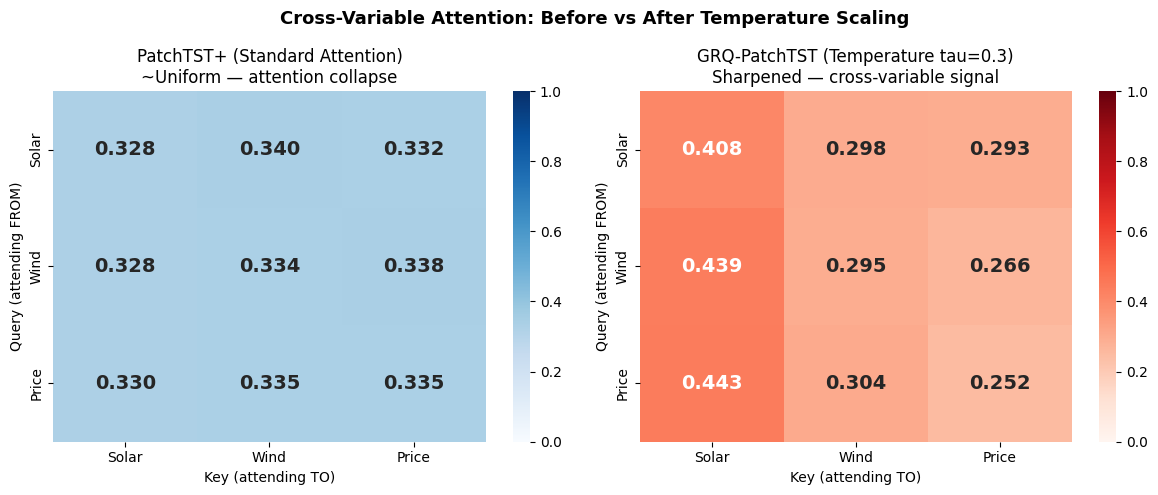

Saved: fig_attn_comparison.png

PatchTST+ max attention weight: 0.340
GRQ-PatchTST max attention weight: 0.443
Higher max = less uniform = better interpretability


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# load old PatchTST+ attention for comparison
attn_old = np.load(f'{BASE}/data/patchtst_plus_attn_weights.npy')  # (n_test, 3, 3)
attn_grq = np.load(f'{BASE}/data/grq_attn_weights.npy')            # (n_test, 3, 3)

target_short = ['Solar', 'Wind', 'Price']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Cross-Variable Attention: Before vs After Temperature Scaling',
             fontsize=13, fontweight='bold')

# PatchTST+ (standard attention — should be ~0.33 uniform)
avg_old = attn_old.mean(axis=0)
sns.heatmap(avg_old, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=target_short, yticklabels=target_short,
            ax=axes[0], vmin=0, vmax=1, annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('PatchTST+ (Standard Attention)\n~Uniform — attention collapse')
axes[0].set_ylabel('Query (attending FROM)')
axes[0].set_xlabel('Key (attending TO)')

# GRQ-PatchTST (temperature-scaled — should show sharper weights)
avg_grq = attn_grq.mean(axis=0)
sns.heatmap(avg_grq, annot=True, fmt='.3f', cmap='Reds',
            xticklabels=target_short, yticklabels=target_short,
            ax=axes[1], vmin=0, vmax=1, annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_title('GRQ-PatchTST (Temperature tau=0.3)\nSharpened — cross-variable signal')
axes[1].set_ylabel('Query (attending FROM)')
axes[1].set_xlabel('Key (attending TO)')

plt.tight_layout()
plt.savefig(f'{BASE}/data/fig_attn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_attn_comparison.png')
print(f'\nPatchTST+ max attention weight: {avg_old.max():.3f}')
print(f'GRQ-PatchTST max attention weight: {avg_grq.max():.3f}')
print('Higher max = less uniform = better interpretability')

# Cell 7 — Quantile Risk Bound Visualization (Best Volatile Window)

Most volatile price window: #3614


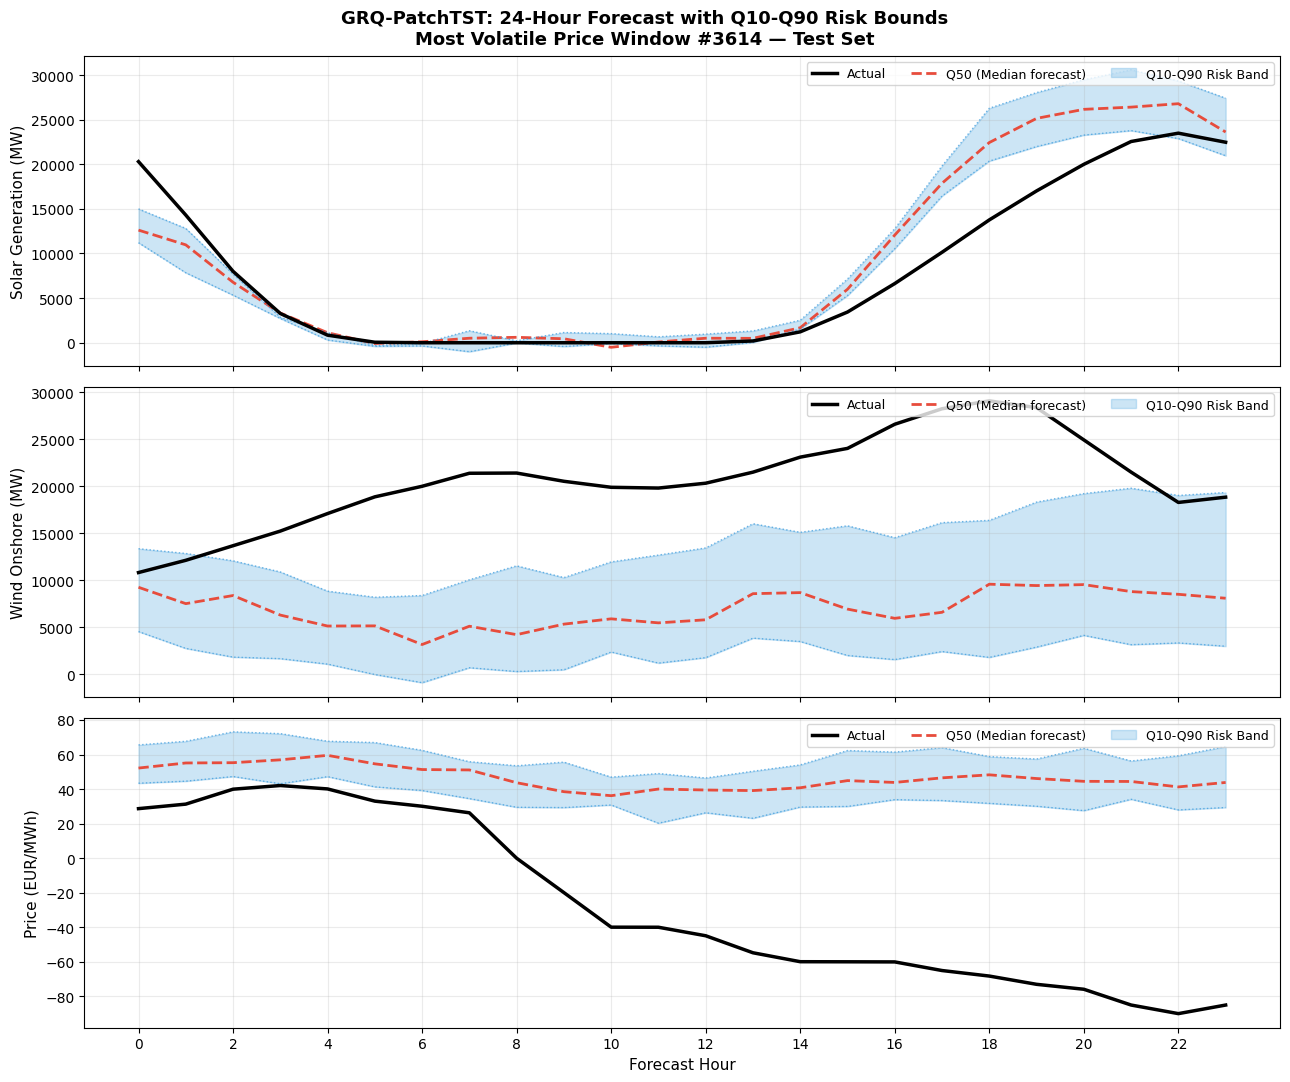

Saved: fig_grq_quantile_bounds.png

── Quantile Coverage (should be ~80% for Q10-Q90 band) ──
  Solar Gen.: 60.7% of actuals within Q10-Q90 band
  Wind Onshore: 64.1% of actuals within Q10-Q90 band
  Price: 41.3% of actuals within Q10-Q90 band


In [8]:
# ── collect all quantile predictions ─────────────────────────────────────
grq_model.eval()
all_preds_q, all_actuals = [], []

with torch.no_grad():
    for x, y in test_loader:
        out, _ = grq_model(x.to(device))    # (B, 24, 3, 3)
        all_preds_q.append(out.cpu().numpy())
        all_actuals.append(y.numpy())

all_preds_q = np.concatenate(all_preds_q)   # (N, 24, 3, 3)
all_actuals = np.concatenate(all_actuals)   # (N, 3, 24)

# ── find window with highest price volatility ─────────────────────────────
price_actual = all_actuals[:, 2, :]          # (N, 24)
price_var    = price_actual.var(axis=1)
best_idx     = int(price_var.argmax())
print(f'Most volatile price window: #{best_idx}')

# ── inverse transform helper ──────────────────────────────────────────────
def inv(arr, i):
    return arr * scales[i] + means[i]

target_labels = ['Solar Generation (MW)', 'Wind Onshore (MW)', 'Price (EUR/MWh)']
hours = np.arange(24)

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
fig.suptitle(f'GRQ-PatchTST: 24-Hour Forecast with Q10-Q90 Risk Bounds\n'
             f'Most Volatile Price Window #{best_idx} — Test Set',
             fontsize=13, fontweight='bold')

for i, (ax, label) in enumerate(zip(axes, target_labels)):
    actual = inv(all_actuals[best_idx, i, :], i)
    q10    = inv(all_preds_q[best_idx, :, i, 0], i)
    q50    = inv(all_preds_q[best_idx, :, i, 1], i)
    q90    = inv(all_preds_q[best_idx, :, i, 2], i)

    ax.plot(hours, actual, color='black',   lw=2.5, label='Actual', zorder=5)
    ax.plot(hours, q50,    color='#E74C3C', lw=2.0, ls='--', label='Q50 (Median forecast)')
    ax.fill_between(hours, q10, q90,
                    color='#3498DB', alpha=0.25, label='Q10-Q90 Risk Band')
    ax.plot(hours, q10,    color='#3498DB', lw=1.0, ls=':', alpha=0.7)
    ax.plot(hours, q90,    color='#3498DB', lw=1.0, ls=':', alpha=0.7)
    ax.set_ylabel(label, fontsize=11)
    ax.legend(loc='upper right', fontsize=9, ncol=3)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Forecast Hour', fontsize=11)
axes[-1].set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig(f'{BASE}/data/fig_grq_quantile_bounds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_grq_quantile_bounds.png')

# ── print quantile coverage stats ────────────────────────────────────────
print('\n── Quantile Coverage (should be ~80% for Q10-Q90 band) ──')
for i, name in enumerate(short):
    actual_i = all_actuals[:, i, :]                   # (N, 24)
    q10_i    = all_preds_q[:, :, i, 0]               # (N, 24)
    q90_i    = all_preds_q[:, :, i, 2]               # (N, 24)
    coverage = ((actual_i >= q10_i) & (actual_i <= q90_i)).mean() * 100
    print(f'  {name}: {coverage:.1f}% of actuals within Q10-Q90 band')

# Cell 8 — Physical Units Summary

FINAL RESULTS IN PHYSICAL UNITS
Model            Target                               MAE           RMSE
------------------------------------------------------------------------
Persistence      Solar Gen.                   1859.7 MW       3761.1 MW  
Persistence      Wind Onshore                 8350.2 MW      11281.6 MW  
Persistence      Price                          10.0 EUR/MWh       15.6 EUR/MWh
------------------------------------------------------------------------
BiLSTM           Solar Gen.                   3397.8 MW       5653.9 MW  
BiLSTM           Wind Onshore                10461.6 MW      12692.0 MW  
BiLSTM           Price                          12.7 EUR/MWh       17.0 EUR/MWh
------------------------------------------------------------------------
PatchTST         Solar Gen.                   4025.8 MW       6885.6 MW  
PatchTST         Wind Onshore                 6634.5 MW       8001.5 MW  
PatchTST         Price                          10.7 EUR/MWh       14.7 

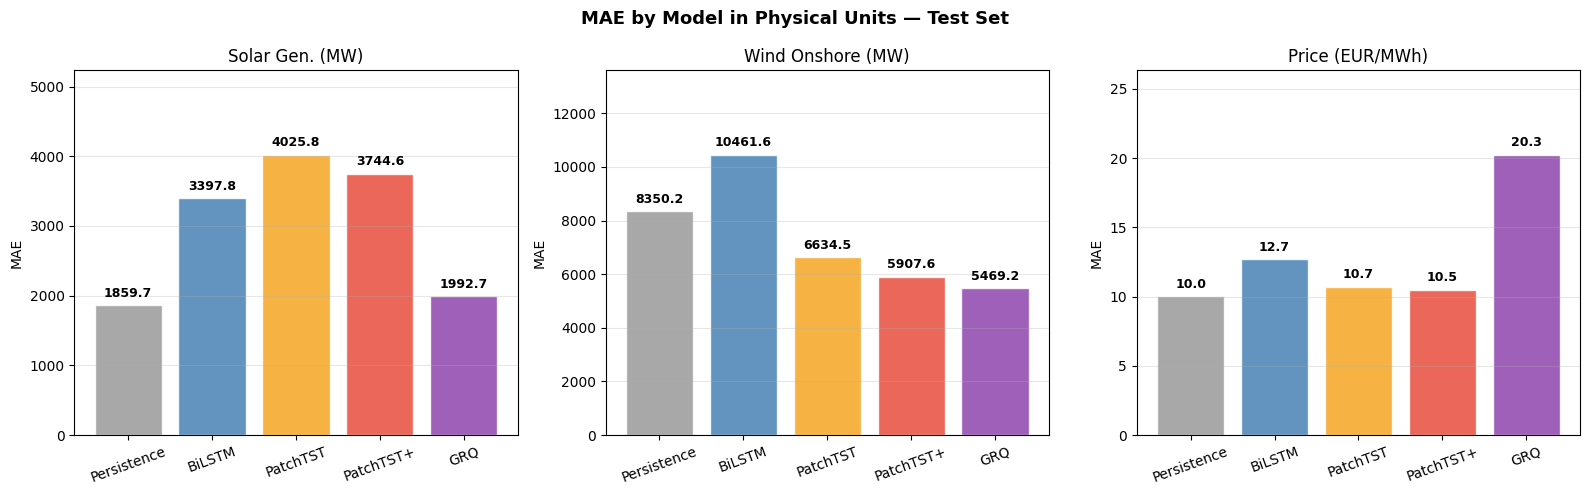

Saved: fig_grq_mae_bar.png


In [9]:
import matplotlib.pyplot as plt

print('='*72)
print('FINAL RESULTS IN PHYSICAL UNITS')
print('='*72)
print(f'{"Model":<16} {"Target":<25} {"MAE":>14} {"RMSE":>14}')
print('-'*72)

for model_name, res in all_results:
    for i, (target, metrics) in enumerate(res.items()):
        real_mae  = metrics['MAE']  * scales[i]
        real_rmse = metrics['RMSE'] * scales[i]
        u = units[i]
        print(f'{model_name:<16} {short[i]:<25} {real_mae:>9.1f} {u:<4}  {real_rmse:>9.1f} {u:<4}')
    print('-'*72)

# ── MAE bar chart with GRQ added ──────────────────────────────────────────
model_names = ['Persistence', 'BiLSTM', 'PatchTST', 'PatchTST+', 'GRQ']
bar_colors  = ['#999999', 'steelblue', '#F5A623', '#E74C3C', '#8E44AD']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('MAE by Model in Physical Units — Test Set', fontsize=13, fontweight='bold')

for i, (ax, tlabel) in enumerate(zip(axes, ['Solar Gen. (MW)', 'Wind Onshore (MW)', 'Price (EUR/MWh)'])):
    maes = [list(res.values())[i]['MAE'] * scales[i] for _, res in all_results]
    bars = ax.bar(model_names, maes, color=bar_colors, alpha=0.85, edgecolor='white')
    ax.set_title(tlabel)
    ax.set_ylabel('MAE')
    ax.set_ylim(0, max(maes) * 1.3)
    for bar, val in zip(bars, maes):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(maes)*0.02,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE}/data/fig_grq_mae_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_grq_mae_bar.png')